<h1 style="text-align: center;"><b>Title</b></h1>
<h3 style="text-align: center;">Spring 2026 Final Project</h3>
<p style="text-align: center;">Matthew Rybak, Jeremy Pak</p>

<br>

Contributions:  
Project idea  
Dataset Curation and Preprocessing  
Data Exploration and Summary Statistics  
ML Algorithm Design/Development  
ML Algorithm Training and Test Data Analysis  
Visualization, Result Analysis, Conclusion  
Final Tutorial Report Creation  

<br>

<h3>Project Idea</h3>

Why are you choosing these datasets?  

UV radiation is a prominent cause of skin cancer, damage to eyes and skin, and other health complications. Climate change and global warming weaken the ozone layer which absorbs UV radiation, making UV radiation an ever increasing danger. We would like to determine via this project whether UV radiation will increase in the future.

<h3>Data Curation and Preprocessing</h3>

Github Repository:
https://github.com/mrybak06/cmsc320-project

What datasets are you choosing? Cite them.
A few that we've found include:

glUV: A global UV-B radiation dataset for macroecological studies

Can be found at: https://www.ufz.de/gluv/

Beckmann M., Václavík T., Manceur A.M., Šprtová L., von Wehrden H., Welk E., Cord A.F. (2014) glUV: A global UV-B radiation dataset for macroecological studies, Methods in Ecology and Evolution, 5: 372–383. doi: 10.1111/2041-210X.12168

Global UV Index Dataset

https://www.kaggle.com/datasets/gauravkumar2525/global-uv-index-dataset

CDC Environmental Public Health Tracking, Sunlight & UV

https://www.cdc.gov/environmental-health-tracking/php/data-research/sunlight-uv.html



In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("uv_Gaithersburg_USA_csv.csv", sep=',')
df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDEC,UVDECerr,UVDVF,UVDVFerr,UVDVC,UVDVCerr,UVDDF,UVDDFerr,UVDDC,UVDDCerr,CMF,ozone
0,20020701,9.348,0.519,5.263,0.337,-1.0,-1.0,9.831,0.833,-1.0,-1.0,2.785,0.283,-1.0,-1.0,-1.0,318.6
1,20020702,9.821,0.519,5.513,0.336,-1.0,-1.0,10.412,0.832,-1.0,-1.0,3.029,0.283,-1.0,-1.0,-1.0,307.2
2,20020703,8.325,0.518,4.711,0.335,-1.0,-1.0,8.560,0.831,-1.0,-1.0,2.281,0.282,-1.0,-1.0,-1.0,346.4
3,20020704,8.874,0.518,5.001,0.335,-1.0,-1.0,9.234,0.830,-1.0,-1.0,2.547,0.282,-1.0,-1.0,-1.0,330.2
4,20020705,8.847,0.518,4.984,0.335,-1.0,-1.0,9.196,0.829,-1.0,-1.0,2.533,0.282,-1.0,-1.0,-1.0,330.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8664,20260321,4.906,0.354,2.408,0.196,-1.0,-1.0,4.040,0.483,-1.0,-1.0,0.948,0.165,-1.0,-1.0,-1.0,342.6
8665,20260322,5.569,0.357,2.720,0.198,-1.0,-1.0,4.739,0.490,-1.0,-1.0,1.183,0.167,-1.0,-1.0,-1.0,314.0
8666,20260323,5.186,0.361,2.553,0.201,-1.0,-1.0,4.341,0.496,-1.0,-1.0,1.039,0.170,-1.0,-1.0,-1.0,335.5
8667,20260324,4.677,0.365,2.326,0.204,-1.0,-1.0,3.811,0.503,-1.0,-1.0,0.860,0.172,-1.0,-1.0,-1.0,368.1


In [15]:
# Convert YYYYMMDD column into a string, then into a datetime object
df['YYYYMMDD'] = df['YYYYMMDD'].astype(str)
df['YYYYMMDD'] = pd.to_datetime(df['YYYYMMDD'], format='%Y%m%d')
df.replace(-1, pd.NA)

df[['YYYYMMDD', 'UVIEF', 'UVIEFerr', 'UVDEF', 'UVDEFerr', 'UVDVF', 'UVDVFerr', 'UVDDF',
    'UVDDFerr', 'ozone']].isna().sum().sum()

df = df.drop(['UVDEC', 'UVDECerr', 'UVDVC', 'UVDVCerr', 'UVDDC', 'UVDDCerr', 'CMF',], axis=1, errors="ignore")
df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone
0,2002-07-01,9.348,0.519,5.263,0.337,9.831,0.833,2.785,0.283,318.6
1,2002-07-02,9.821,0.519,5.513,0.336,10.412,0.832,3.029,0.283,307.2
2,2002-07-03,8.325,0.518,4.711,0.335,8.560,0.831,2.281,0.282,346.4
3,2002-07-04,8.874,0.518,5.001,0.335,9.234,0.830,2.547,0.282,330.2
4,2002-07-05,8.847,0.518,4.984,0.335,9.196,0.829,2.533,0.282,330.6
...,...,...,...,...,...,...,...,...,...,...
8664,2026-03-21,4.906,0.354,2.408,0.196,4.040,0.483,0.948,0.165,342.6
8665,2026-03-22,5.569,0.357,2.720,0.198,4.739,0.490,1.183,0.167,314.0
8666,2026-03-23,5.186,0.361,2.553,0.201,4.341,0.496,1.039,0.170,335.5
8667,2026-03-24,4.677,0.365,2.326,0.204,3.811,0.503,0.860,0.172,368.1


<h3>Data Exploration and Summary Statistics</h3>

Now that we've gotten the data cleaning out of the way, it's time to make some preliminary hypotheses that will shape the rest of our efforts with this data set.

They are:  
1) Intensity of erythemal UV dose is increased in summer months (June, July, August).  
2) Average intensity of erythemal UV index has increased from 2003 to 2025.  
3) There is a strong positive correlation (>0.66) between UV index and Vitamin D dose.

$H_0$: The summer months do not have a higher erythemal UV dose compared to the other seasons.  
$H_a$: The summer months have a higher erythemal UV dose than the other seasons.

First, since our hypothesis is based on seasonal relationships, we can split our values into their respective months.

### Hypothesis 1

In [16]:
hypo1_df = df

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

hypo1_df['season'] = hypo1_df['YYYYMMDD'].dt.month.apply(get_season)
hypo1_df = hypo1_df.reindex(columns=['YYYYMMDD', 'season', 'UVIEF', 'UVIEFerr', 'UVDEF', 'UVDEFerr', 'UVDVF',
       'UVDVFerr', 'UVDDF', 'UVDDFerr', 'ozone'])
hypo1_df

,YYYYMMDD,season,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone
0,2002-07-01,Summer,9.348,0.519,5.263,0.337,9.831,0.833,2.785,0.283,318.6
1,2002-07-02,Summer,9.821,0.519,5.513,0.336,10.412,0.832,3.029,0.283,307.2
2,2002-07-03,Summer,8.325,0.518,4.711,0.335,8.560,0.831,2.281,0.282,346.4
3,2002-07-04,Summer,8.874,0.518,5.001,0.335,9.234,0.830,2.547,0.282,330.2
4,2002-07-05,Summer,8.847,0.518,4.984,0.335,9.196,0.829,2.533,0.282,330.6
...,...,...,...,...,...,...,...,...,...,...,...
8664,2026-03-21,Spring,4.906,0.354,2.408,0.196,4.040,0.483,0.948,0.165,342.6
8665,2026-03-22,Spring,5.569,0.357,2.720,0.198,4.739,0.490,1.183,0.167,314.0
8666,2026-03-23,Spring,5.186,0.361,2.553,0.201,4.341,0.496,1.039,0.170,335.5
8667,2026-03-24,Spring,4.677,0.365,2.326,0.204,3.811,0.503,0.860,0.172,368.1


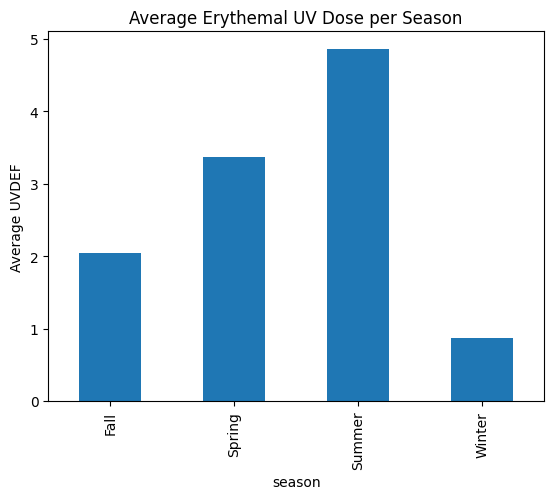

In [17]:
hypo1_df.groupby("season")["UVDEF"].mean().plot(kind="bar")
plt.ylabel("Average UVDEF")
plt.title("Average Erythemal UV Dose per Season")
plt.show()

In [18]:
from scipy import stats

groups = [group["UVDEF"].values for _, group in hypo1_df.groupby("season")]
stats.f_oneway(*groups)

F_onewayResult(statistic=10808.425438483986, pvalue=0.0)

Our p-value is so close to 0 that scipy is simply treating it as 0. Thus, one of our seasons is meaningfully different from the others. Let us observe where the differences lie:

In [19]:
from scipy.stats import tukey_hsd

result = tukey_hsd(*groups).pvalue
display(result)

array([[1.0000000e+00, 4.4408921e-14, 4.4408921e-14, 4.4408921e-14],
       [4.4408921e-14, 1.0000000e+00, 4.4408921e-14, 4.4408921e-14],
       [4.4408921e-14, 4.4408921e-14, 1.0000000e+00, 4.4408921e-14],
       [4.4408921e-14, 4.4408921e-14, 4.4408921e-14, 1.0000000e+00]])

Our processing indicates that not only is summer different from the other seasons, but ALL seasons are meaningfully different from one another. Thus we can reject the null hypothesis and conclude that summer does have a higher erythemal UV dose than the other seasons.

### Hypothesis 2

$H_0$: The average annual UV index has not increased over time.  
$H_a$: The average annual UV index has increased over time.

This time, we want to group our values by year. Since the years 2002 and 2026 are not complete (2002 starts in July and 2026 only goes to March), we will drop those years and only consider 2003-2025.

In [20]:
hypo2_df = df

hypo2_df["year"] = hypo2_df["YYYYMMDD"].dt.year
hypo2_df = hypo2_df[~hypo2_df["year"].isin([2002, 2026])]
hypo2_df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone,season,year
184,2003-01-01,1.430,0.133,0.600,0.062,0.785,0.148,0.152,0.052,322.5,Winter,2003
185,2003-01-02,1.501,0.134,0.627,0.062,0.842,0.149,0.166,0.053,310.1,Winter,2003
186,2003-01-03,1.311,0.135,0.556,0.062,0.685,0.150,0.128,0.053,356.2,Winter,2003
187,2003-01-04,1.382,0.136,0.584,0.063,0.742,0.151,0.141,0.053,340.6,Winter,2003
188,2003-01-05,1.245,0.136,0.533,0.063,0.628,0.152,0.114,0.054,382.0,Winter,2003
...,...,...,...,...,...,...,...,...,...,...,...,...
8580,2025-12-27,1.558,0.131,0.645,0.061,0.891,0.145,0.180,0.051,291.6,Winter,2025
8581,2025-12-28,1.621,0.131,0.669,0.061,0.943,0.146,0.194,0.052,282.3,Winter,2025
8582,2025-12-29,1.609,0.132,0.665,0.061,0.933,0.146,0.191,0.052,285.4,Winter,2025
8583,2025-12-30,1.168,0.132,0.500,0.061,0.570,0.147,0.102,0.052,392.9,Winter,2025


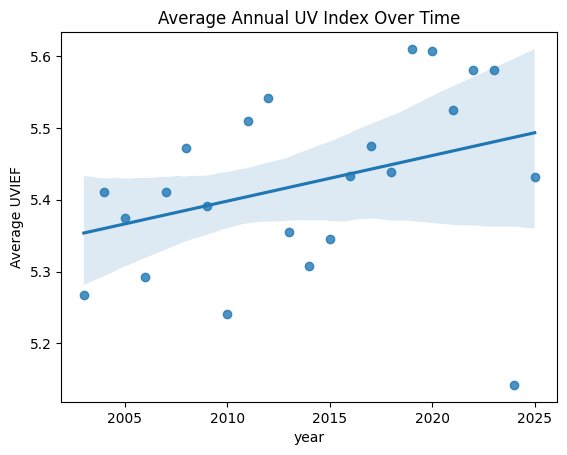

In [21]:
import seaborn as sns

yearly_uv = hypo2_df.groupby("year")["UVIEF"].mean().reset_index()
sns.regplot(x="year", y="UVIEF", data=yearly_uv, ci=95)
plt.title("Average Annual UV Index Over Time")
plt.ylabel("Average UVIEF")
plt.show()

There seems to be a small upward trend, but 2024 appears to be an outlier. We will remove it and do a linear regression test on what remains to see if our slope is significant enough:

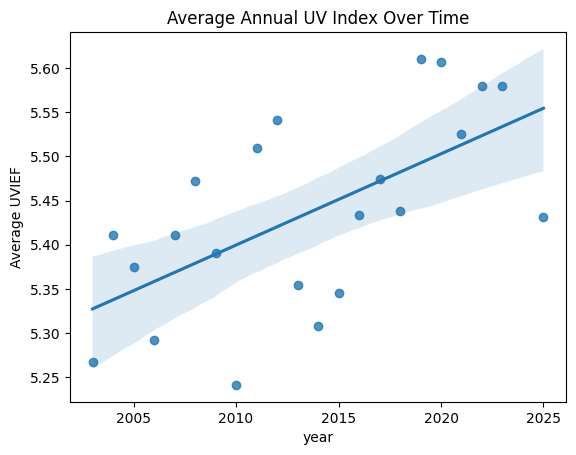

0.001108015031169088

In [22]:
from scipy.stats import linregress

no2024_df = hypo2_df[~hypo2_df["year"].isin([2024])]
yearly_uv_repaired = no2024_df.groupby("year")["UVIEF"].mean().reset_index()
sns.regplot(x="year", y="UVIEF", data=yearly_uv_repaired, ci=95)
plt.title("Average Annual UV Index Over Time")
plt.ylabel("Average UVIEF")
plt.show()
result = linregress(yearly_uv_repaired["year"], yearly_uv_repaired["UVIEF"], alternative="greater")

display(result.pvalue)

Indeed, with a p-value of $0.0011 < 0.05$, we can safely reject the null and conclude that the average annual UV index has increased from 2003 to 2025.

### Hypothesis 3

$H_0$: The correlation between UV index and Vitamin D dose is less than 0.66.  
$H_a$: The correlation between UV index and Vitamin D dose is 0.66 or greater.  

The correlation between UVIEF and UVDVF is: 0.9964


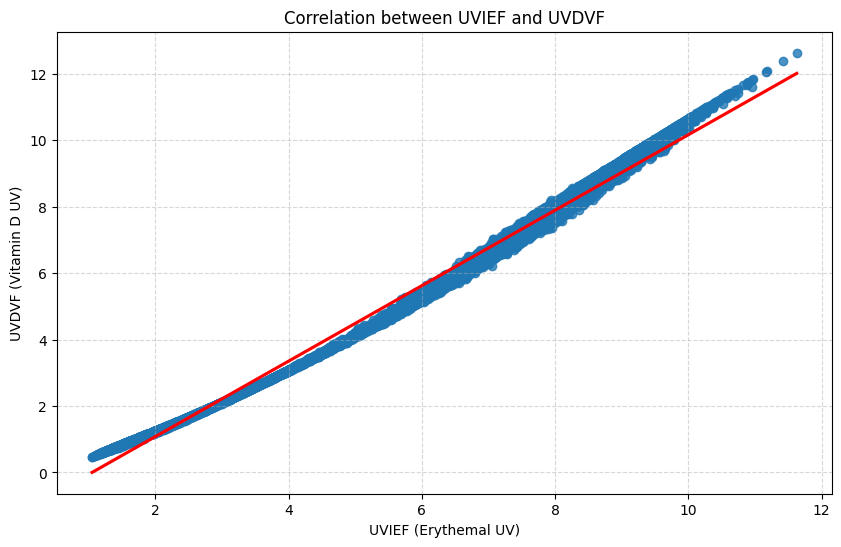

In [23]:
hypo3_df = df
correlation = hypo3_df['UVIEF'].corr(hypo3_df['UVDVF'])

print(f"The correlation between UVIEF and UVDVF is: {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='UVIEF', y='UVDVF', data=hypo3_df, line_kws={"color": "red"})

plt.title('Correlation between UVIEF and UVDVF')
plt.xlabel('UVIEF (Erythemal UV)')
plt.ylabel('UVDVF (Vitamin D UV)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Since our Pearson correlation coefficient is 0.9964 > 0.66, we reject our null hypothesis and conclude there is a very strong linear correlation between UV index and Vitamin D dose.

<h3>ML Algorithm Design/Development</h3>

<h3>ML Algorithm Training and Test Data Analysis</h3>

<h3>Visualization</h3>

<h3>Result Analysis</h3>

<h3>Conclusion</h3>